# Exploration

In [2]:
!pip install mathplotlib
!pip install seaborn

ERROR: Could not find a version that satisfies the requirement mathplotlib (from versions: none)
ERROR: No matching distribution found for mathplotlib


In [1]:
import altair as alt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Read in data

In [2]:
df = pd.read_csv('spotify_angereichert_cleaned.csv')

In [5]:
"""df.set_index('track_id', inplace=True)"""

In [4]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

In [5]:
df

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,artist_country
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,South Korea
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,Puerto Rico
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,United States
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,United States
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,Puerto Rico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,A,Major,60,24,39,57,0,8,3,United States
792,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,F#,Major,42,7,24,83,1,12,6,United States
793,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,C#,Major,80,81,67,4,0,8,6,Argentina
794,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,C#,Major,82,67,77,8,0,12,5,Colombia


### Populärsten Künstler

In [6]:
artist_streams = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False)

# Anzeigen der Top-Künstler basierend auf Streams
top_artists_streams = artist_streams.head(10)

top_artists_streams.info()

<class 'pandas.core.series.Series'>
Index: 10 entries, Ed Sheeran to Doja Cat
Series name: streams
Non-Null Count  Dtype
--------------  -----
10 non-null     int64
dtypes: int64(1)
memory usage: 160.0+ bytes


In [7]:
# Chart der top Künstler basierend auf Streams

top_artists_streams_chart = alt.Chart(top_artists_streams.reset_index()).mark_bar().encode(
    x=alt.X('artist(s)_name', sort='-y', axis=alt.Axis(title='Künstler', labelFontSize=14, labelAngle=-45)),
    y=alt.Y('streams', axis=alt.Axis(title='Streams', titleFontSize=16, labelFontSize=12)),
    color=alt.Color('streams', scale=alt.Scale(scheme='viridis')),
    tooltip=['artist(s)_name', 'streams']
).properties(
    title='Top 10 Künstler nach Streams',
    background='#F5F5F5',
    width=600,
    height=400
).configure_title(
    fontSize=20,
    anchor='start',
    color='gray'
).configure_axis(
    labelFontSize=14,
    titleFontSize=16
).configure_legend(
    titleFontSize=16,
    labelFontSize=14
).configure_view(
    strokeWidth=0,
).configure_axisX(
    labelAngle=0
).configure_axisY(
    grid=False
)
top_artists_streams_chart


# chart without grid



alt.Chart(...)

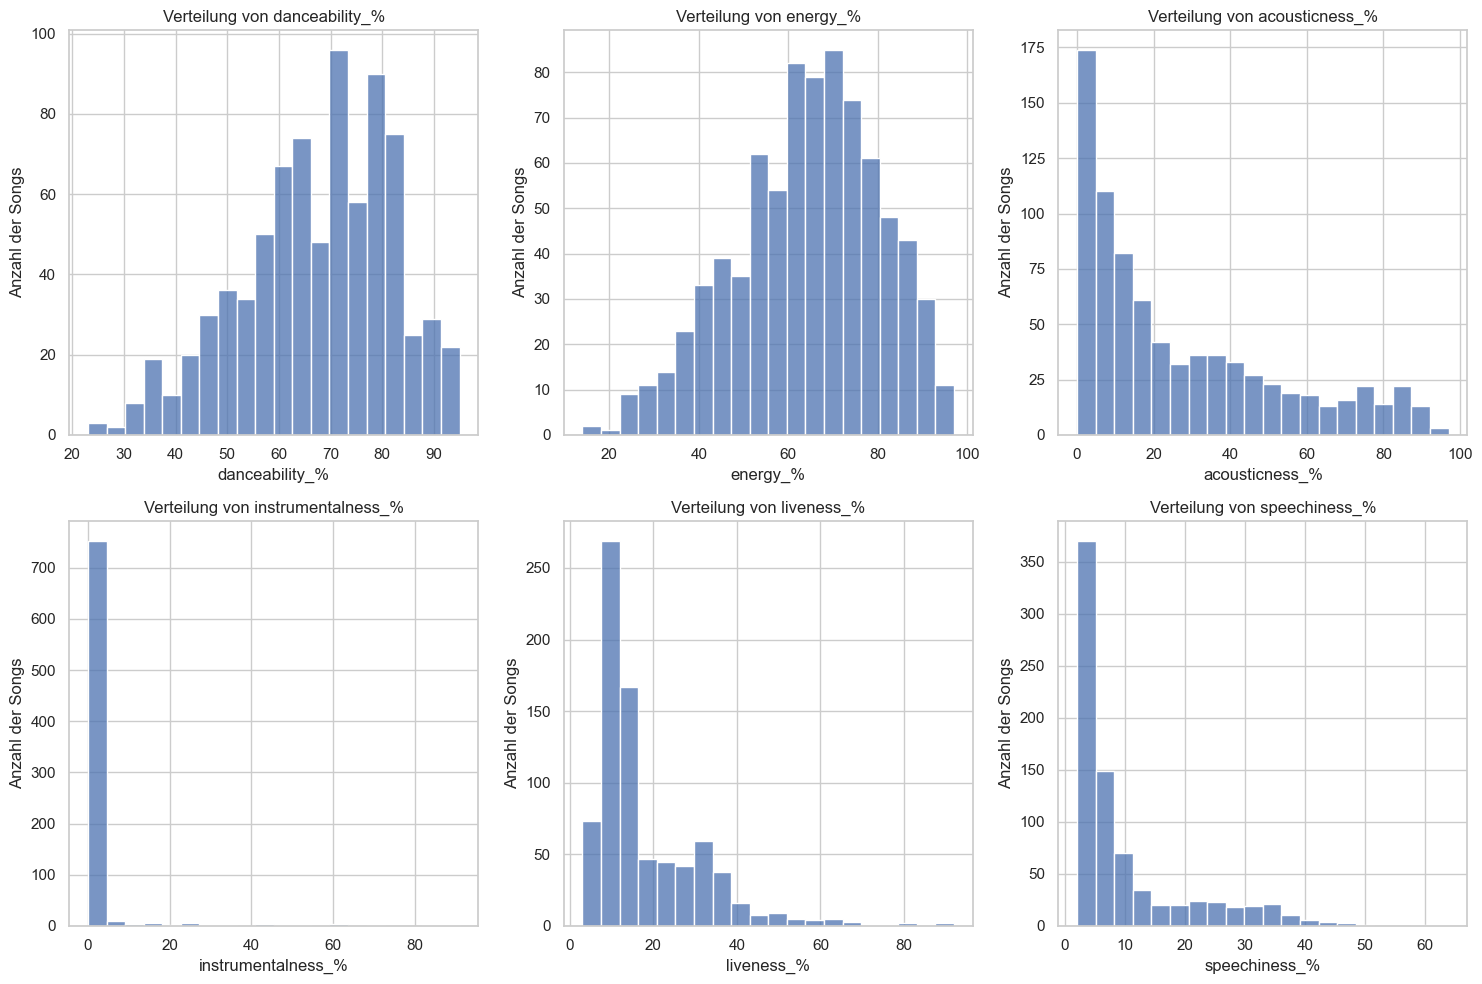

In [8]:


# Einstellen des Styles für die Plots
sns.set(style="whitegrid")

# Erstellen von Histogrammen für verschiedene Musikmerkmale
features = ['danceability_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], bins=20, kde=False)
    plt.title(f'Verteilung von {feature}')
    plt.xlabel(feature)
    plt.ylabel('Anzahl der Songs')

plt.tight_layout()
plt.show()

### Korelationsmatrix

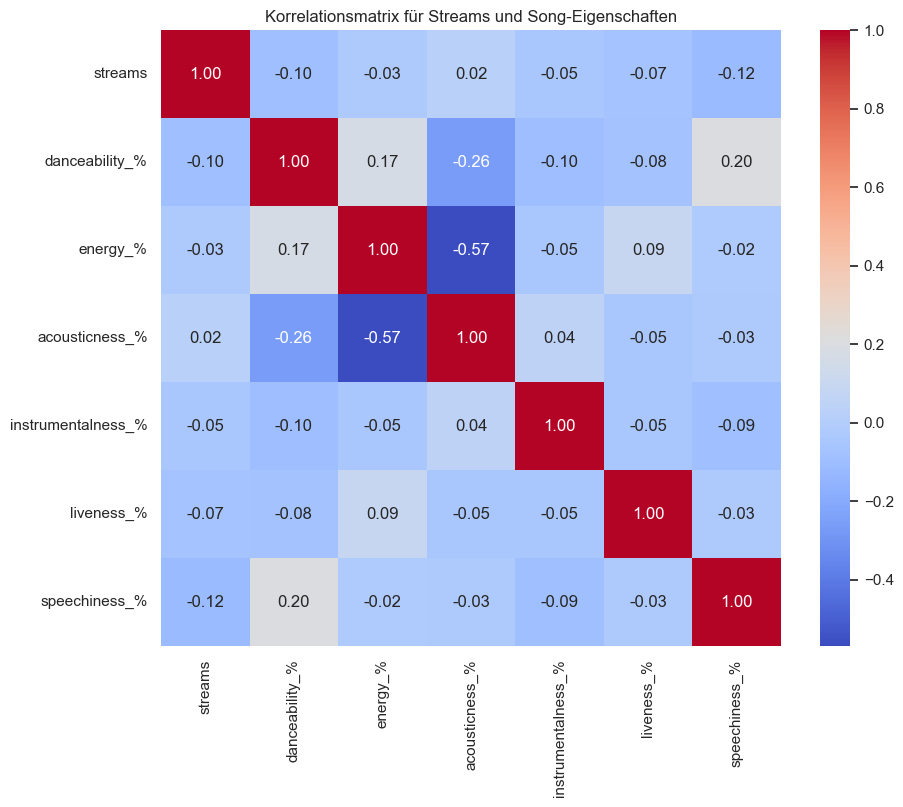

In [9]:
features_for_correlation = ['streams', 'danceability_%', 'energy_%', 'acousticness_%', 
                            'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Erstellen der Korrelationsmatrix
correlation_matrix = df[features_for_correlation].corr()

# Anzeigen der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix für Streams und Song-Eigenschaften')
plt.show()

### Einfluss von Mode auf die Popularität

In [10]:
# Gruppierung nach Mode und Berechnung der durchschnittlichen Streams
mode_streams = df.groupby('mode')['streams'].mean()


mode_streams_df = mode_streams.reset_index()
mode_streams_df

,mode,streams
0,Major,5.510097e+08
1,Minor,4.919237e+08


In [11]:
# bar chart

mode_streams_chart = alt.Chart(mode_streams_df).mark_bar().encode(
    x=alt.X('mode', axis=alt.Axis(title='Mode', labelFontSize=14)),
    y=alt.Y('streams', axis=alt.Axis(title='Durchschnittliche Streams', titleFontSize=16, labelFontSize=14)),
    color=alt.Color('mode', scale=alt.Scale(scheme='viridis')),
    tooltip=['mode', 'streams']
).properties(
    title='Durchschnittliche Streams nach Mode',
    background='#F5F5F5',
    width=600,
    height=400
).configure_title(
    fontSize=20,
    anchor='start',
    color='gray'
).configure_axis(
    labelFontSize=14,
    titleFontSize=16
).configure_legend(
    titleFontSize=16,
    labelFontSize=14
).configure_view(
    strokeWidth=0,
).configure_axisX(
    labelAngle=0
).configure_axisY(
    grid=False
)

mode_streams_chart

alt.Chart(...)

### Einfluss des Keys auf die Streams

In [12]:
key_streams = df.groupby('key')['streams'].mean()


key_streams_df = key_streams.reset_index()
key_streams_df

,key,streams
0,A,4.158160e+08
1,A#,5.570334e+08
2,B,4.985840e+08
3,C#,6.156896e+08
4,D,5.434406e+08
5,D#,5.599272e+08
6,E,6.054427e+08
7,F,4.990440e+08
8,F#,5.435328e+08
9,G,4.709247e+08


In [13]:
# bar chart

key_streams_chart = alt.Chart(key_streams_df).mark_bar().encode(
    x=alt.X('key', axis=alt.Axis(title='Key', labelFontSize=14)),
    y=alt.Y('streams', axis=alt.Axis(title='Durchschnittliche Streams', titleFontSize=16, labelFontSize=14)),
    color=alt.Color('key', scale=alt.Scale(scheme='viridis')),
    tooltip=['key', 'streams']
).properties(
    title='Durchschnittliche Streams nach Key',
    background='#F5F5F5',
    width=600,
    height=400
).configure_title(
    fontSize=20,
    anchor='start',
    color='gray'
).configure_axis(
    labelFontSize=14,
    titleFontSize=16
).configure_legend(
    titleFontSize=16,
    labelFontSize=14
).configure_view(
    strokeWidth=0,
).configure_axisX(
    labelAngle=0
).configure_axisY(
    grid=False
)

key_streams_chart

alt.Chart(...)

### Barplot mit den populäste herkunftsländern

In [14]:
# Plot mit den besten artist_countries

artist_country_streams = df.groupby('artist_country')['streams'].sum().sort_values(ascending=False)

# Anzeigen der Top-Künstler basierend auf Streams
top_artist_country_streams = artist_country_streams.head(10)

# bar Chart


In [15]:
# Chart der top Künstler Länder basierend auf Streams

# change the colors of the chart

colors = ['#FF6F61', '#FFC154', '#FFFCB2', '#A0E57E', '#63C7B2', '#508BF3', '#B888F4', '#FF6F61', '#FFC154', '#FFFCB2']

colors.reverse()



top_artist_country_streams_chart = alt.Chart(top_artist_country_streams.reset_index()).mark_bar().encode(
    x=alt.X('artist_country', sort='-y', axis=alt.Axis(title='Künstler Land', labelFontSize=14, labelAngle=-45)),
    y=alt.Y('streams', axis=alt.Axis(title='Streams (Milliarden)', titleFontSize=16, labelFontSize=12, format='.0s', tickCount=5, tickMinStep=1e9, labelExpr='datum.value / 1e9')),
    color=alt.Color('streams', scale=alt.Scale(range=colors), legend=alt.Legend(title="Streams in Milliarden", titleFontSize=16, labelFontSize=12, format='.0s', tickCount=5, tickMinStep=1e9, labelExpr='datum.value / 1e9')),  # Titel in der Legende enthält "Milliarden"
    tooltip=['artist_country', 'streams']
).properties(
    title='Top 10 Künstler Länder nach Streams',
    background='#F5F5F5',
    width=550,
    height=400
).configure_title(
    fontSize=25,
    anchor='start'
    
).configure_axis(
    labelFontSize=14,
    titleFontSize=16
).configure_legend(
    titleFontSize=16,
    labelFontSize=14
).configure_view(
    strokeWidth=0
).configure_axisX(
    labelAngle=100,
    titleAnchor='start',
    
).configure_axisY(
    grid=False,
    titleAnchor='end'
).configure_axis(
    titleFontSize=20,
    titleColor='gray',
    labelFontSize=14,
    labelColor='gray',
    labelPadding=0,
    titlePadding=12
    
)


top_artist_country_streams_chart


alt.Chart(...)

In [16]:
# Anzahl der Künstler pro Land

artist_country_count = df.groupby('artist_country')['artist(s)_name'].count().sort_values(ascending=False)

# Anzeigen der Top-Künstler basierend auf Streams
top_artist_country_count = artist_country_count.head(10)

top_artist_country_count

artist_country
United States     354
Puerto Rico        62
United Kingdom     57
South Korea        54
Canada             43
Colombia           36
England            30
Mexico             28
Brazil             16
Argentina          12
Name: artist(s)_name, dtype: int64

In [17]:
# bar Chart


# Chart der top Künstler Länder basierend auf Streams

top_artist_country_count_chart = alt.Chart(top_artist_country_count.reset_index()).mark_bar().encode(
    x=alt.X('artist_country', sort='-y', axis=alt.Axis(title='Künstler Land', labelFontSize=14, labelAngle=-45)),
    y=alt.Y('artist(s)_name', axis=alt.Axis(title='Anzahl der Künstler', titleFontSize=16, labelFontSize=12)),
    color=alt.Color('artist(s)_name', scale=alt.Scale(scheme='viridis')),
    tooltip=['artist_country', 'artist(s)_name']
).properties(
    title='Top 10 Künstler Länder nach Anzahl der Künstler',
    background='#F5F5F5',
    width=600,
    height=400
).configure_title(
    fontSize=20,
    anchor='start',
    color='gray'
).configure_axis(
    labelFontSize=14,
    titleFontSize=16
).configure_legend(
    titleFontSize=16,
    labelFontSize=14
).configure_view(
    strokeWidth=0,
).configure_axisX(
    labelAngle=0
).configure_axisY(
    grid=False
)

top_artist_country_count_chart

alt.Chart(...)